In [1]:
import numpy as np
import pandas as pd

alexandria_profile = (
    pd.read_csv("inputs/rhp155.txt", sep=";", header=None, names=["depth", "x"])
    .set_index("x")
    .rolling(window=1)
    .mean()
    .dropna()
    .drop_duplicates()
)

new_x = np.arange(
    np.round(alexandria_profile.index.min()),
    np.round(alexandria_profile.index.max()),
    1,
)

alexandria_profile = alexandria_profile.reindex(
    new_x, method="nearest", tolerance=0.5
).interpolate(method="linear")
alexandria_profile

,depth
x,
-40.0,1.390
-39.0,1.391
-38.0,1.392
-37.0,1.393
-36.0,1.394
...,...
2492.0,-10.700
2493.0,-10.700
2494.0,-10.700


<Axes: xlabel='x'>

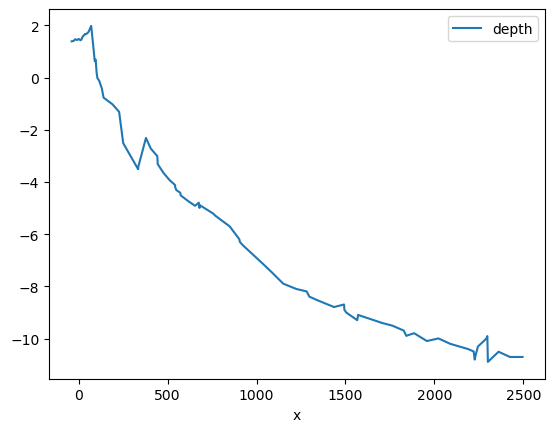

In [2]:
alexandria_profile.plot()

In [3]:
alexandria_profile = -alexandria_profile.values[::-1].reshape(-1)
alexandria_profile

array([10.7  , 10.7  , 10.7  , ..., -1.392, -1.391, -1.39 ])

Text(0.5, 1.0, 'Alexandria Profile')

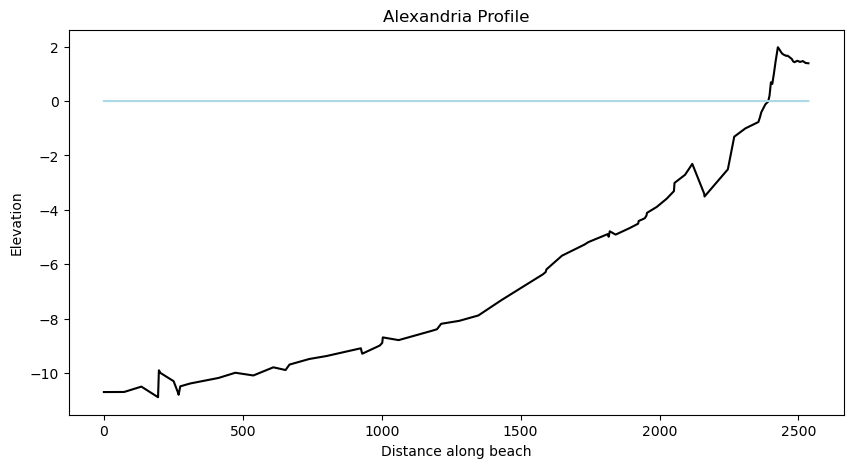

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
plt.plot(-alexandria_profile, c="k")
plt.plot(
    range(len(alexandria_profile)), np.repeat(0, len(alexandria_profile)), "lightblue"
)
plt.xlabel("Distance along beach")
plt.ylabel("Elevation")
plt.title("Alexandria Profile")

In [5]:
from bluemath_tk.wrappers._utils_wrappers import write_array_in_file
from bluemath_tk.wrappers.swash.swash_wrapper import SwashModelWrapper


class CustomSwashWrapper(SwashModelWrapper):
    """
    Custom SWASH wrapper that inherits from SwashModelWrapper.
    """

    def build_case(self, case_context: dict, case_dir: str) -> None:
        super().build_case(case_context=case_context, case_dir=case_dir)
        write_array_in_file(self.depth_array, f"{case_dir}/depth.bot")

In [6]:
metamodel_parameters = {
    "Hs": [0.5, 1.0, 2.0],
    "Hs_L0": [0.01],
}
metamodel_parameters

{'Hs': [0.5, 1.0, 2.0], 'Hs_L0': [0.01]}

In [7]:
swan_wrapper = CustomSwashWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters={
        "dxinp": 1,  # bathymetry grid spacing  # Friction manning coefficient (m^-1/3 s)
        "comptime": 300,  # Simulation duration (s)
        "warmup": 300,  # Warmup duration (s)
        "n_nodes_per_wavelength": 60,  # number of nodes per wavelength
    },
    output_dir="CASES",
    depth_array=alexandria_profile,
)
swan_wrapper.build_cases(mode="all_combinations")

In [8]:
swan_wrapper.run_cases_in_background(launcher="serial", num_workers=3)

In [18]:
swan_wrapper.monitor_cases()

,Case,Status
0,0000,END
1,0001,END
2,0002,END


In [19]:
postprocessed_cases = swan_wrapper.postprocess_cases()
postprocessed_cases

<xarray.Dataset> Size: 405kB
Dimensions:   (case_num: 3, Tsec: 600, Xp: 2537)
Coordinates:
  * case_num  (case_num) int64 24B 0 1 2
  * Tsec      (Tsec) int64 5kB 0 1 2 3 4 5 6 7 ... 593 594 595 596 597 598 599
  * Xp        (Xp) int64 20kB 0 1 2 3 4 5 6 ... 2531 2532 2533 2534 2535 2536
    Yp        int64 8B 0
Data variables:
    Ru2       (case_num) float64 24B 0.1956 0.6095 1.909
    Runlev    (case_num, Tsec) float64 14kB 0.0 0.0 0.0 ... 1.476 1.476 1.476
    Msetup    (case_num, Xp) float64 61kB 0.0008433 2.95e-05 ... 1.391 1.39
    Hrms      (case_num, Xp) float64 61kB 0.5064 0.5025 0.5015 ... 0.0 0.0
    Hs        (case_num, Xp) float64 61kB 0.7175 0.7121 0.7107 ... 1.622e-15 0.0
    Hss       (case_num, Xp) float64 61kB 0.7175 0.7121 0.7107 ... 5.882e-19 0.0
    ig        (case_num, Xp) float64 61kB 0.001864 0.002037 ... 1.622e-15 0.0
    Hvlf      (case_num, Xp) float64 61kB 0.001738 0.001902 ... 1.518e-15 0.0

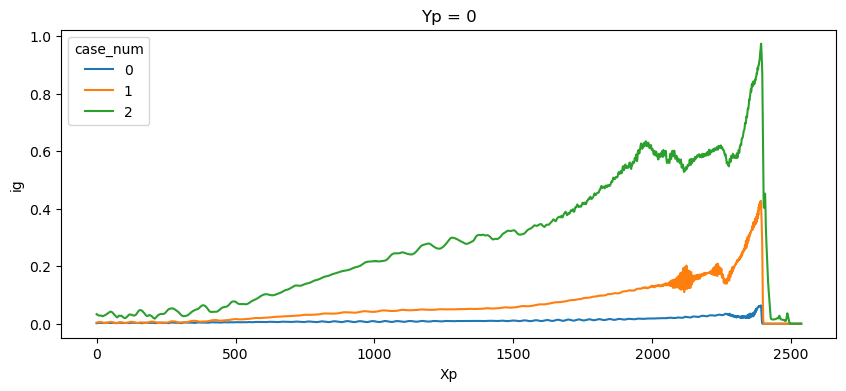

In [20]:
postprocessed_cases.ig.plot(hue="case_num", figsize=(10, 4))